In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df=pd.read_csv(r'dataset\predictive_maintenance.csv')

In [6]:
df.shape

(10000, 10)

In [5]:
df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  str    
dtypes: float64(3), int64(4), str(3)
memory usage: 950.2 KB


In [8]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [34]:
df.sample(20)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
4620,4621,L51800,L,303.1,311.3,1336,52.6,172,1,Heat Dissipation Failure
7367,7368,M22227,M,299.5,310.1,1359,61.1,67,0,No Failure
3383,3384,H32797,H,301.4,310.6,1674,33.6,49,0,No Failure
6691,6692,M21551,M,301.7,311.0,1510,47.8,27,0,No Failure
1144,1145,L48324,L,297.0,307.9,1296,69.1,153,1,Power Failure
7975,7976,M22835,M,301.2,312.3,1548,38.3,87,0,No Failure
6235,6236,L53415,L,301.3,310.9,1596,33.9,157,0,No Failure
5548,5549,L52728,L,302.3,311.8,1605,35.2,152,0,No Failure
9660,9661,M24520,M,298.9,309.8,1392,43.1,218,0,No Failure
6278,6279,L53458,L,301.2,310.7,1568,38.3,49,0,No Failure


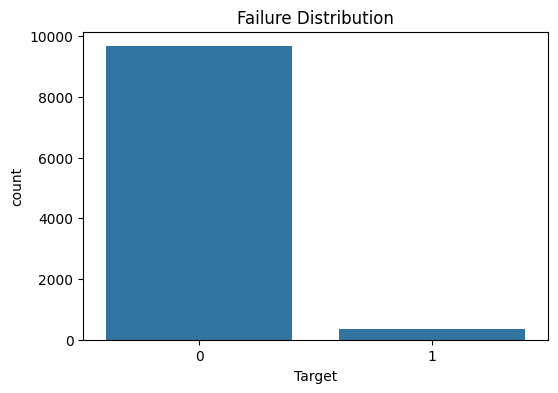

Target
0    9661
1     339
Name: count, dtype: int64


In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Target',
    data=df
)

plt.title('Failure Distribution')
plt.show()

print(df['Target'].value_counts())

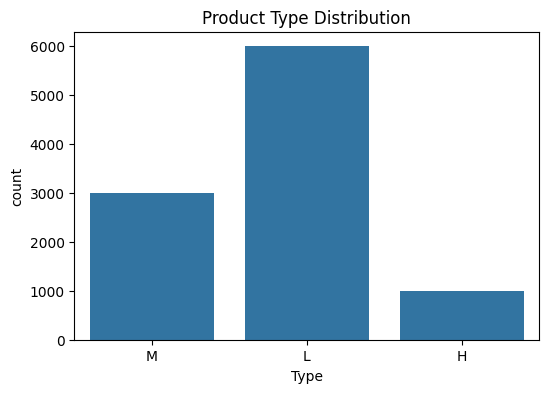

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Type',
    data=df
)

plt.title('Product Type Distribution')
plt.show()

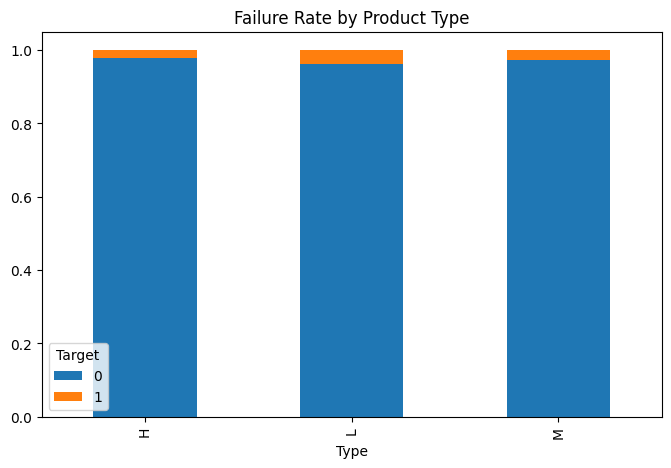

In [12]:
failure_by_type = pd.crosstab(
    df['Type'],
    df['Target'],
    normalize='index'
)

failure_by_type.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title("Failure Rate by Product Type")
plt.show()

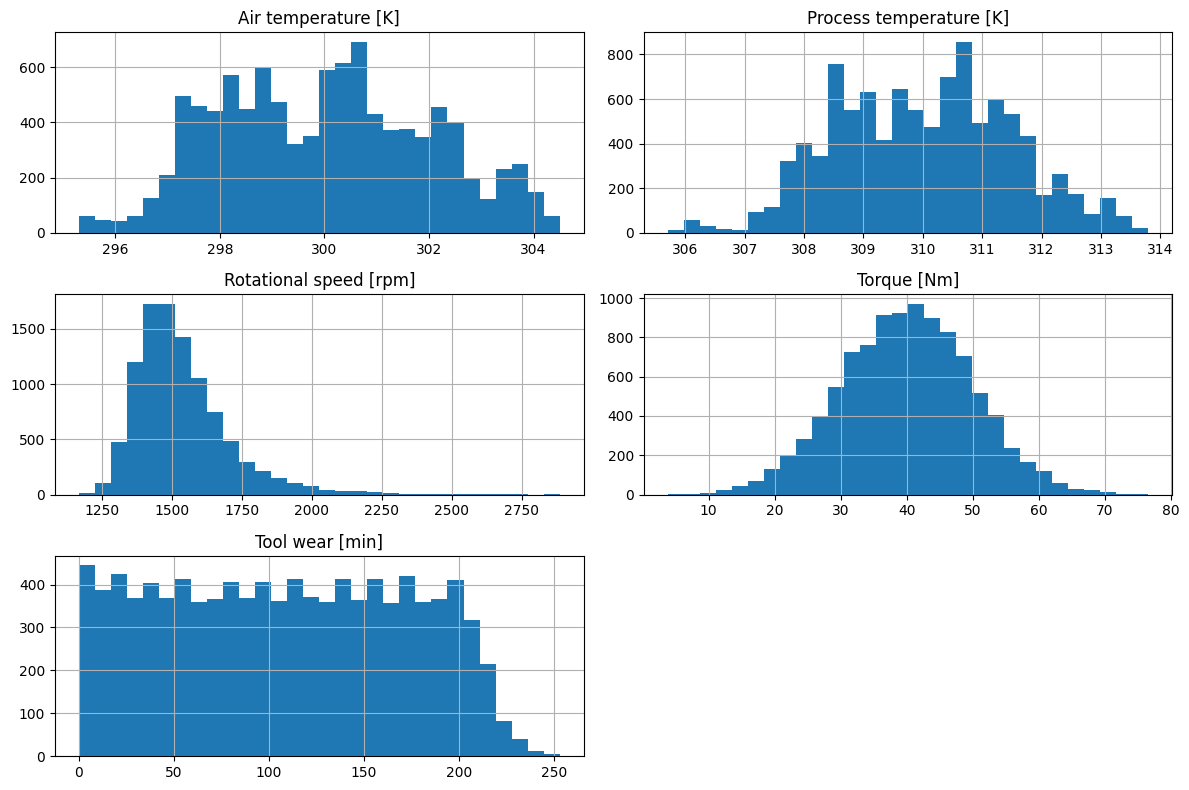

In [13]:
features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

df[features].hist(
    figsize=(12,8),
    bins=30
)

plt.tight_layout()
plt.show()

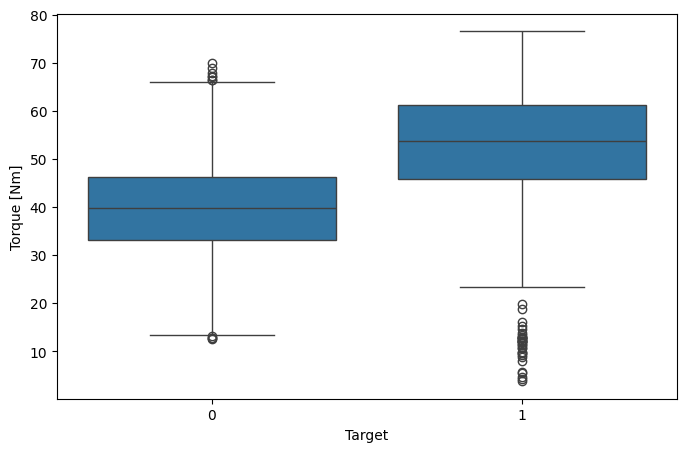

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Target',
    y='Torque [Nm]',
    data=df
)

plt.show()

During Failures, torque mean is greater and more outliers

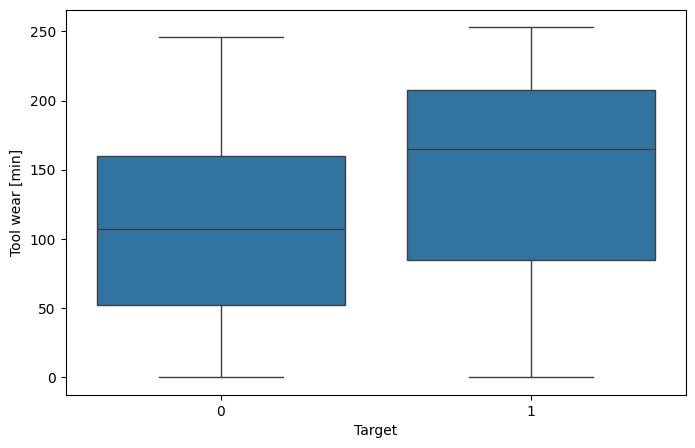

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Target',
    y='Tool wear [min]',
    data=df
)

plt.show()

during failures, tool wear is also high

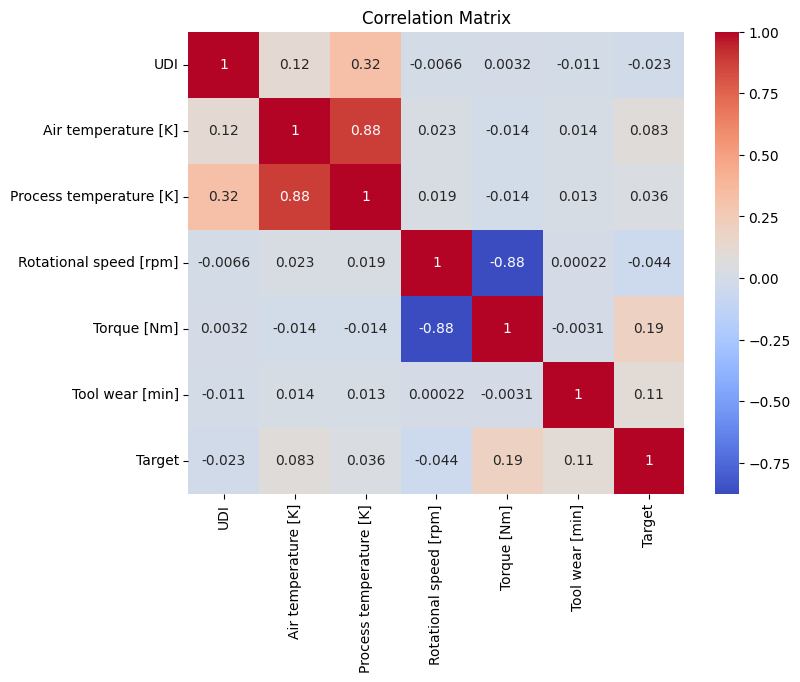

In [16]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [35]:
df['Temp_Diff'] = (
    df['Process temperature [K]']
    - df['Air temperature [K]']
)

In [36]:
df['Torque_Wear'] = (
    df['Torque [Nm]']
    * df['Tool wear [min]']
)

In [38]:
df['Torque_RPM'] = (
    df['Torque [Nm]']
    * df['Rotational speed [rpm]']
)

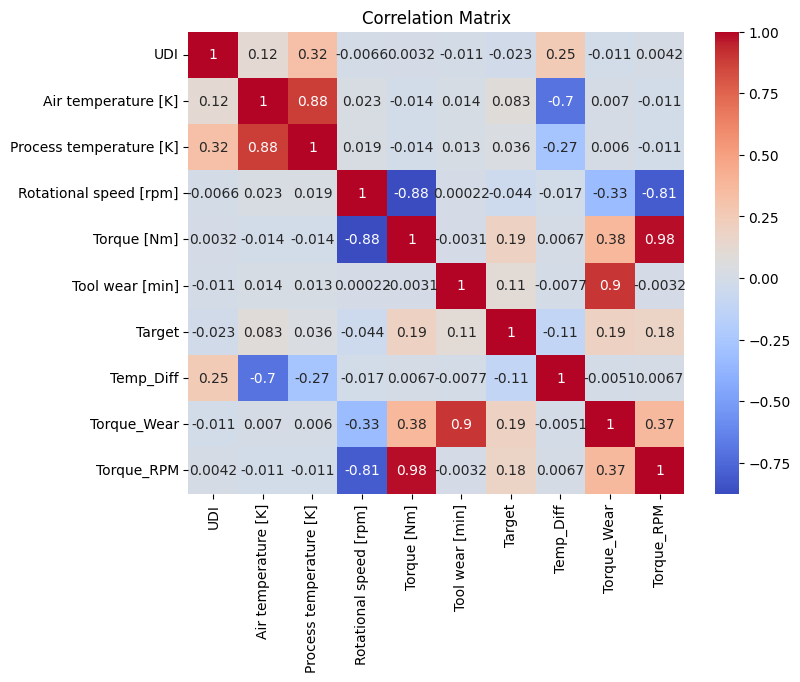

In [39]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [40]:
df['Failure Type'].value_counts()

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

In [41]:
X = df.drop(
    columns=[
        'UDI',
        'Product ID',
        'Failure Type',
        'Target'
    ]
)

y = df['Target']

In [42]:
X['Temp_Diff'] = (
    X['Process temperature [K]']
    - X['Air temperature [K]']
)

X['Torque_Wear'] = (
    X['Torque [Nm]']
    * X['Tool wear [min]']
)

X['Torque_RPM'] = (
    X['Torque [Nm]']
    * X['Rotational speed [rpm]']
)

In [43]:
X = pd.get_dummies(
    X,
    columns=['Type'],
    drop_first=True
)

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [46]:
from sklearn.metrics import classification_report

preds = rf.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.96      0.75      0.84        68

    accuracy                           0.99      2000
   macro avg       0.98      0.87      0.92      2000
weighted avg       0.99      0.99      0.99      2000



In [47]:
rf.feature_importances_

array([0.0458369 , 0.02728987, 0.206209  , 0.18622179, 0.13612932,
       0.08898302, 0.12179312, 0.17953602, 0.00368138, 0.00431959])

In [48]:
X.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp_Diff,Torque_Wear,Torque_RPM,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,10.5,0.0,66382.8,False,True
1,298.2,308.7,1408,46.3,3,10.5,138.9,65190.4,True,False
2,298.1,308.5,1498,49.4,5,10.4,247.0,74001.2,True,False
3,298.2,308.6,1433,39.5,7,10.4,276.5,56603.5,True,False
4,298.2,308.7,1408,40.0,9,10.5,360.0,56320.0,True,False


EDA suggested:

Torque is the most important factor.

The model says:

Rotational Speed + Torque together are even more important.